# 6주차 2차시: 시계열 분석 & 멀티자산 비교

| 주제 | 내용 |
|---|---|
| 이동평균 | SMA · EMA 비교 시각화 |
| Trend Decomposition | `seasonal_decompose` (trend + seasonality + residual) |
| 멀티자산 비교 | 4종 ETF 누적수익률 |
| 상관관계 | `returns.corr()` 히트맵 |
| 성과 지표 | 연환산 수익률·변동성·Sharpe·MDD |
| LLM 리포트 | 계산형 vs. LLM-only 비교 |
| DataFrame 병합 | `concat` · `merge` · `reindex + ffill` |


In [1]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 24.6 MB/s eta 0:00:00


In [3]:
import os, json, math
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from dotenv import load_dotenv
# load_dotenv()
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
MODEL = "gpt-4o-mini"

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

## 전일(14일) 실습자료 이어서 — 시계열 분석 개요

- 이동 평균, 트렌드 분해(decomposition), 이상 탐지, 분포 분석

1. 이동평균
  - 서버 트래픽, 이커머스 구매내역, 센서 데이터, 온도 등등
  - 이동평균 사용하는 이유: 노이즈
  - S(standard)MA : 최근 N개의 평균
  - E(exponential)MA : 최근 값에 더 큰 가중치를 두는 MA (웹 트래픽, 트렌드 등)

2. 트렌드 분해
  - 시계열 데이터에는
  - 트렌드 : 장기적으로 매출이 상승/하락. 전반적으로 연령별 타겟 시장이 커진다 등
  - Seasonality (계절성, 주기 등): 여름에 잘팔리고 겨울에는 안팔리는 등..
  - Residual (잔차) : 나머지 (트렌드 및 Seasonality로 표현되지 않는 나머지 부분)

In [4]:
!pip install statsmodels

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [8]:
!pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 1.1 MB/s eta 0:00:00


In [10]:
import FinanceDataReader as fdr

In [11]:
ticker = "069500"
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')

end_date, start_date

('2026-04-15', '2025-04-15')

In [12]:
price_df = fdr.DataReader(ticker, start_date, end_date)

In [13]:
sample_df = price_df.copy()

In [15]:
ffill_df = sample_df.copy() #

In [16]:
close = ffill_df['Close']
close

,Close
Date,
2025-04-15,32692
2025-04-16,32183
2025-04-17,32501
2025-04-18,32722
2025-04-21,32766
...,...
2026-04-09,87250
2026-04-10,88655
2026-04-13,87880


## 이동평균 (SMA · EMA)

시계열 노이즈를 완화하고 추세를 드러내는 기본 기법.

| 방식 | 수식 | 특징 |
|---|---|---|
| SMA | `rolling(N).mean()` | 최근 N 개 평균, 균등 가중 |
| EMA | `ewm(span=N).mean()` | 최근 값에 더 큰 가중치, 반응 빠름 |


In [17]:
sma_20 = close.rolling(20).mean()
ema_20 = close.ewm(span=20).mean()

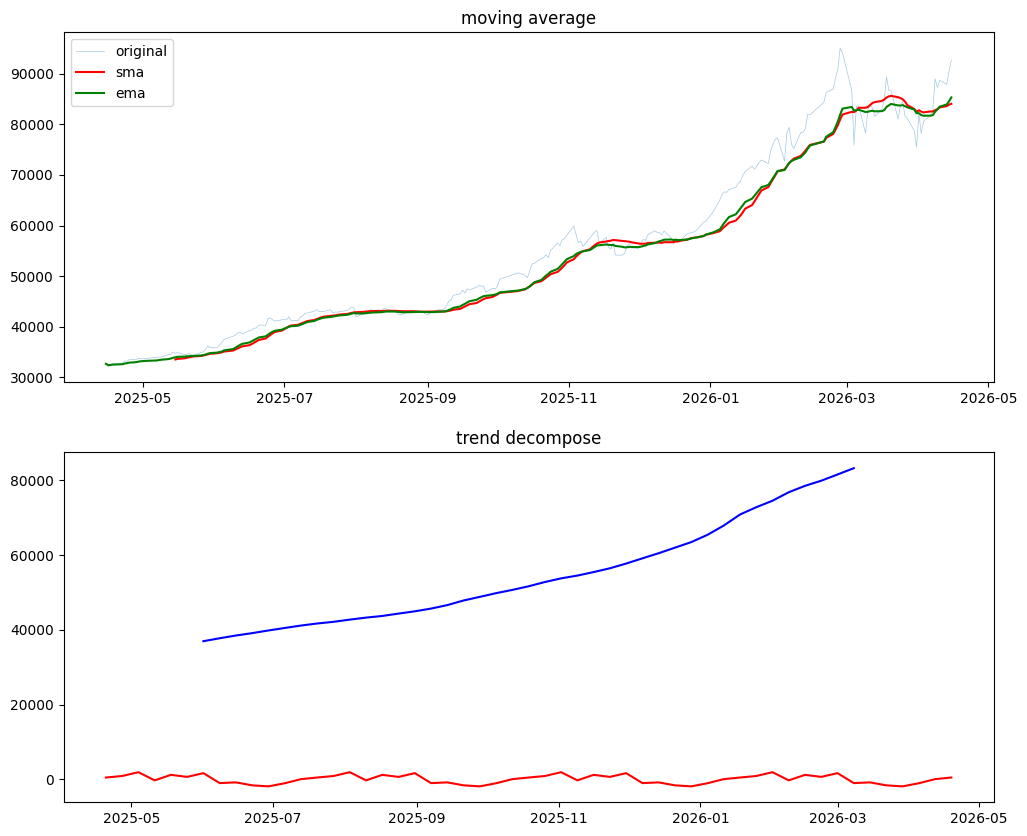

In [21]:
fig, axes = plt.subplots(2, 1, figsize = (12,10)) # 2행 1열 구조의 차트 생성
ax = axes[0]
ax.plot(close.index, close, alpha = 0.4, linewidth = 0.5, label = 'original') # 원본 종가 데이터
ax.plot(sma_20.index, sma_20, linewidth=1.5, label = 'sma', color = 'red') # 20일 단순이동평균
ax.plot(ema_20.index, ema_20, linewidth=1.5, label = 'ema', color = 'green') # 20일 지수이동평균
ax.set_title('moving average') # 차트 제목 설정
ax.legend() # 범례 표시

weekly = close.resample('W').last().dropna() # 주간 단위 데이터로 변환 (결측치 제거)
decomp = seasonal_decompose(weekly, model = 'additive', period = 13) # 계절성 분해 (13주 주기)
axes[1].plot(decomp.trend.index, decomp.trend, label='trend', linewidth = 1.5, color = 'blue') # 분해된 성분 중 트렌드(추세) 시각화
axes[1].plot(decomp.seasonal.index, decomp.seasonal, label = 'seasonal', linewidth = 1.5, color = 'red')
axes[1].set_title('trend decompose')

plt.show()



## Trend Decomposition

시계열을 구성요소로 분해하여 구조 이해.

- `statsmodels.tsa.seasonal.seasonal_decompose`
- 가법(additive) 모델: `time_series = trend + seasonality + residual`
- 승법(multiplicative) 모델: `time_series = trend * seasonality * residual`


In [ ]:
# time-series data : trend + seasonality + (residual)
#                    trend * seasonality + (residual)
# 해석 두가지.

## 멀티자산 비교

서로 다른 자산군(국내주식·미국주식·채권·원자재) ETF 4종을 같은 기간으로 수집하여 비교.

- 각 티커별 종가를 하나의 DataFrame `multi_close` 로 통합
- `pct_change()` → 일별 수익률, `(1 + r).cumprod()` → 누적 수익률
- 동일 축에 그려 상대 성과 비교


In [22]:
tickers = {
    '069500': 'KODEX 200 (국내주식)',
    '360750': 'TIGER S&P500 (미국주식)',
    '152380': 'KODEX 국고채10년 (채권)',
    '132030': 'KODEX 골드선물 (원자재)',
}

In [23]:
multi_close = pd.DataFrame() # 빈 데이터프레임 생성

In [24]:
# 딕셔너리에 있는 애들을 for loop을 돌면서

for ticker, name in tickers.items():
  df = fdr.DataReader(ticker, start = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d'))
  multi_close[name] = df['Close']


In [25]:
multi_close.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-15,32692,18972,70736,19189
2025-04-16,32183,18720,70899,19582
2025-04-17,32501,18616,70860,19806
2025-04-18,32722,18621,70993,19851
2025-04-21,32766,18334,71127,20135


In [26]:
multi_close = multi_close.dropna()

In [27]:
returns = multi_close.pct_change().dropna()

In [28]:
returns.head() # 4월 16일부터 시작하는걸 볼 수 있음(pct_change 때문)

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-16,-0.015570,-0.013283,0.002304,0.020480
2025-04-17,0.009881,-0.005556,-0.000550,0.011439
2025-04-18,0.006800,0.000269,0.001877,0.002272
2025-04-21,0.001345,-0.015413,0.001888,0.014307
2025-04-22,-0.003296,-0.009436,-0.001111,0.028408


In [29]:
cum_returns = (1+ returns).cumprod()

In [30]:
cum_returns.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-16,0.984430,0.986717,1.002304,1.020480
2025-04-17,0.994158,0.981236,1.001753,1.032154
2025-04-18,1.000918,0.981499,1.003633,1.034499
2025-04-21,1.002264,0.966371,1.005528,1.049299
2025-04-22,0.998960,0.957253,1.004411,1.079108


In [31]:
cum_returns.tail()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2026-04-09,2.668849,1.314042,0.950718,1.397415
2026-04-10,2.711826,1.323266,0.948880,1.408359
2026-04-13,2.688119,1.321157,0.946477,1.400281
2026-04-14,2.766120,1.335125,0.951566,1.410965
2026-04-15,2.834486,1.344877,0.952980,1.426077


In [32]:
cum_returns.columns

Index(['KODEX 200 (국내주식)', 'TIGER S&P500 (미국주식)', 'KODEX 국고채10년 (채권)',
       'KODEX 골드선물 (원자재)'],
      dtype='object')

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

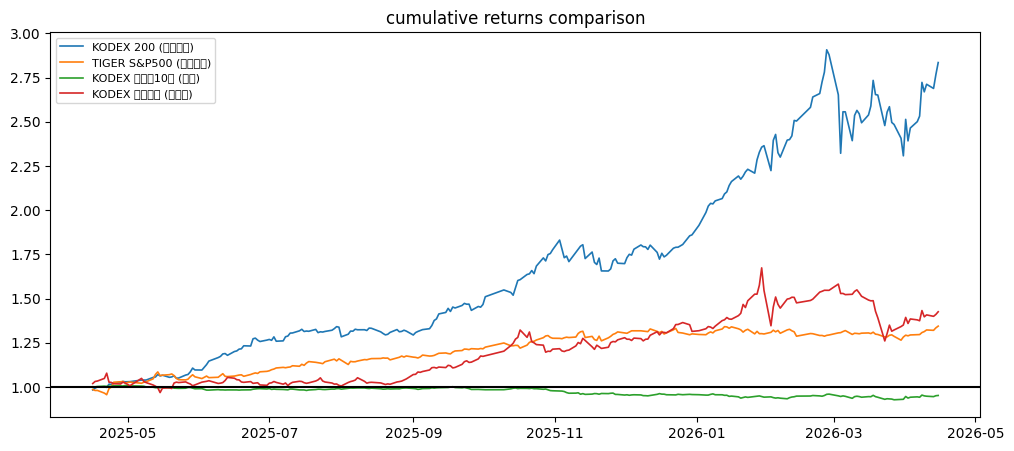

In [36]:
fig, ax = plt.subplots(figsize = (12, 5))
for col in cum_returns.columns:
  ax.plot(cum_returns.index, cum_returns[col], label=col, linewidth = 1.2)

ax.axhline(1.0, color = 'black')
ax.legend(fontsize=8) # 어떤게 어떤건지 구별하려면 범례(legend) 추가
ax.set_title('cumulative returns comparison')
plt.show()

## 상관관계 분석

자산 간 수익률 상관을 통해 분산투자 효과를 진단.

- `returns.corr()` — 피어슨 상관계수 행렬
- `imshow` + 수치 어노테이션으로 히트맵 시각화
- 상관이 낮을수록 포트폴리오 리스크 분산 효과 큼


In [38]:
# 상관관계

returns.corr() # 각각의 속성(column)들이 어떤 상관관계인지 파악 (pearson 상관관계)

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
KODEX 200 (국내주식),1.000000,0.293541,0.389003,0.383096
TIGER S&P500 (미국주식),0.293541,1.000000,0.031366,-0.068603
KODEX 국고채10년 (채권),0.389003,0.031366,1.000000,0.165718
KODEX 골드선물 (원자재),0.383096,-0.068603,0.165718,1.000000


In [40]:
corr_matrix = returns.corr()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44264 (\N{HANGUL SYLLABLE GOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

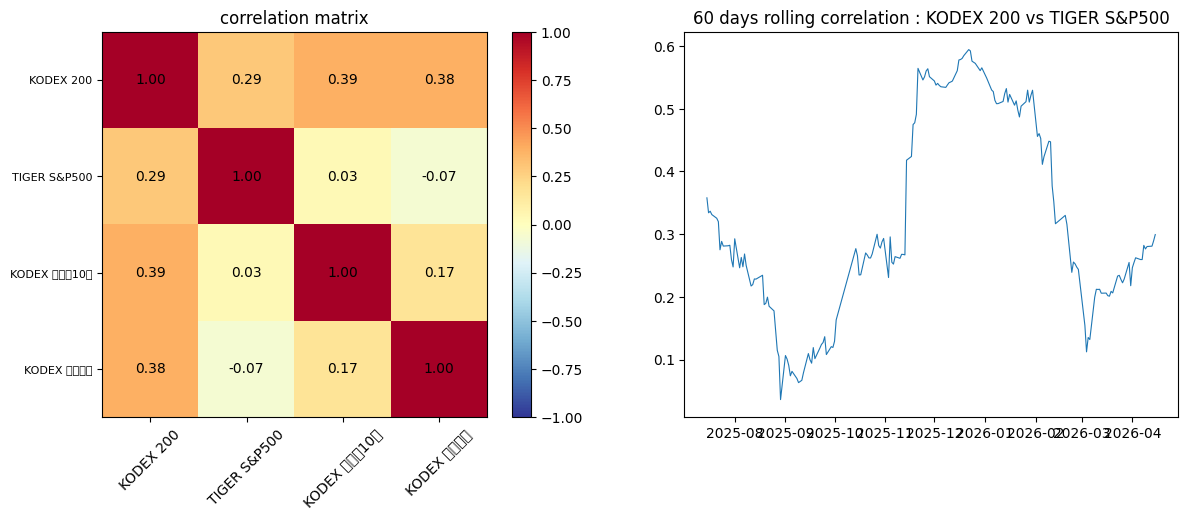

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) # 1행 2열 구조 생성 (ax1: 왼쪽 자리, ax2: 오른쪽 자리)
im = ax1.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1) # ax1(왼쪽)에 상관관계 히트맵을 그림
ax1.set_xticks(range(len(corr_matrix)))
ax1.set_yticks(range(len(corr_matrix)))
short_names = [c.split('(')[0].strip() for c in corr_matrix.columns]
ax1.set_xticklabels(short_names, rotation=45)
ax1.set_yticklabels(short_names, fontsize= 8)

for i in range(len(corr_matrix)):
  for j in range(len(corr_matrix)):
    ax1.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va = 'center')

fig.colorbar(im, ax=ax1)
ax1.set_title('correlation matrix')

#

cols = returns.columns.tolist()
if len(cols) >=2:
  rolling_corr = returns[cols[0]].rolling(60).corr(returns[cols[1]])
  ax2.plot(rolling_corr.index, rolling_corr, linewidth=0.8)
  ax2.set_title(f'60 days rolling correlation : {short_names[0]} vs {short_names[1]}')

plt.show()

## 성과 지표 계산

자산 성과를 비교 가능한 수치로 요약.

| 지표 | 의미 |
|---|---|
| 연환산 수익률 | `(1 + daily_mean) ** 252 - 1` |
| 연환산 변동성 | `daily_std * sqrt(252)` |
| Sharpe Ratio | `(ann_ret - rf) / ann_vol` — 위험 대비 초과수익 |
| MDD | 누적수익률 기준 최대 낙폭 (Max Drawdown) |


In [49]:
def calculate_metrics(returns_series, risk_free = 0.035):
  # 수익률, 변동성, MDD, 샤프
  ann_ret = (1+ returns_series.mean()) ** 252 - 1
  ann_vol = returns_series.std() * np.sqrt(252)
  sharpe = (ann_ret - risk_free) / ann_vol

  cum = (1 + returns_series).cumprod()
  mdd = ((cum - cum.cummax()) / cum.cummax()).min()

  return {
      'yearly return' : f"{ann_ret * 100:.1f}%",
      'yearly volatile' : f"{ann_vol * 100:.1f}%",
      'MDD' : f"{mdd * 100:.1f}%",
      'sharpe': f"{sharpe:.1f}"

  }


In [50]:
metrics_rows = []
for col in returns.columns:
  m = calculate_metrics(returns[col])
  m['ETF'] = col.split('(')[0].strip()
  metrics_rows.append(m)

In [51]:
metrics_rows

[{'yearly return': '215.0%',
  'yearly volatile': '36.6%',
  'MDD': '-20.6%',
  'sharpe': '5.8',
  'ETF': 'KODEX 200'},
 {'yearly return': '37.2%',
  'yearly volatile': '13.3%',
  'MDD': '-5.7%',
  'sharpe': '2.5',
  'ETF': 'TIGER S&P500'},
 {'yearly return': '-4.7%',
  'yearly volatile': '5.7%',
  'MDD': '-8.0%',
  'sharpe': '-1.4',
  'ETF': 'KODEX 국고채10년'},
 {'yearly return': '51.8%',
  'yearly volatile': '31.1%',
  'MDD': '-24.7%',
  'sharpe': '1.6',
  'ETF': 'KODEX 골드선물'}]

In [52]:
metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,yearly return,yearly volatile,MDD,sharpe,ETF
0,215.0%,36.6%,-20.6%,5.8,KODEX 200
1,37.2%,13.3%,-5.7%,2.5,TIGER S&P500
2,-4.7%,5.7%,-8.0%,-1.4,KODEX 국고채10년
3,51.8%,31.1%,-24.7%,1.6,KODEX 골드선물


In [54]:
metrics_df = pd.DataFrame(metrics_rows).set_index('ETF')
metrics_df

,yearly return,yearly volatile,MDD,sharpe
ETF,,,,
KODEX 200,215.0%,36.6%,-20.6%,5.8
TIGER S&P500,37.2%,13.3%,-5.7%,2.5
KODEX 국고채10년,-4.7%,5.7%,-8.0%,-1.4
KODEX 골드선물,51.8%,31.1%,-24.7%,1.6


## DataFrame을 LLM에 입력하여 데이터 분석할 예정
- 이전에 했던 것들
  - 데이터 가져와서 정제
  - 분석, 전처리
- 이후에 LLM 이용한 분석
- 금융 챗봇 프로젝트에서는
  1. 데이터 수집, 전처리
  2. 데이터 분석
  -  ---------------- raw data
  3. 데이터 만들기 : RAG를 만들고 사용자가 쿼리를 날렸을 때 참고할 데이터 = RAG 성능 평가를 위한 데이터 생성
  4. RAG 구현
  5. 프로젝트

In [ ]:
metrics_df.to_string()

In [55]:
def generate_analysis_insight(metric_df):
  response = ChatOpenAI(model = 'gpt-4o-mini', temperature = 0.3, max_tokens = 400).invoke([
   {'role': 'system', 'content' : '당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다.'},
   {'role': 'user', 'content': f"""아래 ETF 비교 데이터를 분석하여 투자 인사이트를 작성하세요.

   {metrics_df.to_string()}

    다음 형식으로 답하세요:
    1. 핵심 발견(3줄)
    2. 위험 요인(2줄)
    3. 분산 투자 제안(2줄)
   """}
  ])

  return response.content

In [56]:
insight = generate_analysis_insight(metrics_df)


In [57]:
print(insight)

1. 핵심 발견: KODEX 200은 215.0%의 높은 연간 수익률을 기록하며 가장 뛰어난 성과를 보였습니다. TIGER S&P500도 안정적인 수익률(37.2%)을 제공하지만, KODEX 200에 비해 수익성이 낮습니다. KODEX 국고채10년은 부정적인 수익률을 보이며, 안전 자산으로서의 역할이 제한적입니다.

2. 위험 요인: KODEX 200은 높은 변동성(36.6%)을 가지고 있어, 투자자에게 큰 가격 변동 위험을 안겨줄 수 있습니다. KODEX 골드선물은 MDD가 -24.7%로 손실 가능성이 크며, 안전 자산으로서의 신뢰도가 낮습니다.

3. 분산 투자 제안: KODEX 200과 TIGER S&P500을 조합하여 높은 수익률과 안정성을 동시에 추구하는 전략이 유효할 수 있습니다. 또한, KODEX 국고채10년과 KODEX 골드선물을 포함시켜 포트폴리오의 리스크를 분산시키는 것이 바람직합니다.


### 종목 단위 분석 리포트 — 지표 계산 + LLM 결합형

수익률·SMA·변동성 등 **파이썬에서 계산한 핵심 수치**를 프롬프트에 주입하여 LLM 이 해석·설명을 작성.

- LLM 은 숫자 계산이 불안정하므로 계산은 코드로, 서술은 LLM 으로 분담


In [ ]:
def generate_analysis_report(ticker_name, close_prices):
  # 수익률 {returns}
  # price_df = fdr.DataReader(ticker, start_date, end_date)
  # close = price_df['Close']

  close = close_prices

  sma_20 = close.rolling(20).mean()
  ema_20 = close.ewm(span=20).mean()
  current_close = close.iloc[-1]
  rolling_std = close.rolling(20).std()


  response = ChatOpenAI(model = 'gpt-4o-mini', temperature = 0.3, max_tokens = 400).invoke([
   {'role': 'system', 'content' : '당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다.'},
   {'role': 'user', 'content': f"""{ticker_name}에 대한 분석 보고서를 작성하세요.

    [현재 지표 데이터]
    - 현재 종가: {current_close:.2f}
    - 20일 단순이동평균(SMA): {sma_20:.2f}
    - 20일 지수이동평균(EMA): {ema_20:.2f}
    - 20일 변동성(Rolling Std): {rolling_std:.2f}

    다음 형식으로 답하세요:
    1. 핵심 발견(3줄)
    2. 위험 요인(2줄)
    3. 분산 투자 제안(2줄)
   """}
  ])

  return response.content




In [59]:
!pip install scipy

In [60]:
!pip install scikit-learn

In [70]:
# 강사님 코드

def generate_analysis_report(ticker_name, close_prices):
  returns = close_prices.pct_change().dropna()
  sma_20 = close_prices.rolling(20).mean().iloc[-1]
  sma_60 = close_prices.rolling(60).mean().iloc[-1]
  current = close_prices.iloc[-1] # iloc은 데이터프레임을 인덱스로 접근하는 방법

  roll_mean = returns.rolling(30).mean()
  roll_std = returns.rolling(30).std()
  z_latest = ((returns - roll_mean) / roll_std).iloc[-1]

  from scipy.stats import skew, kurtosis # 전체적인 통계값을 제공해준다면 LLM이 판단하기 수월할 수 있음
  # 왜도(Skewness): 분포의 좌우 비대칭 정도(비대칭 방향과 꼬리의 길이)
  # 첨도(kurtosis) : 분포의 뾰족함과 꼬리 두께(데이터가 중심에 몰린 정도)를 나타냄

  sk = skew(returns.dropna())
  kt = kurtosis(returns.dropna())

  vol_recent = returns[-20:].std() * np.sqrt(252) * 100
  vol_overall = returns.std() * np.sqrt(252) * 100

  indicators = {
        '현재가': f'{current:,.0f}',
        'SMA(20)': f'{sma_20:,.0f}',
        'SMA(60)': f'{sma_60:,.0f}',
        '추세': '상승' if sma_20 > sma_60 else '하락',
        '최근 롤링 Z-score': f'{z_latest:.2f}',
        '이상 여부': '정상' if abs(z_latest) < 2 else '주의' if abs(z_latest) < 3 else '이상',
        'Skewness': f'{sk:.3f}',
        'Kurtosis': f'{kt:.3f}',
        '최근 20일 변동성': f'{vol_recent:.1f}%',
        '전체 변동성': f'{vol_overall:.1f}%',
        '변동성 변화': '확대' if vol_recent > vol_overall else '축소',
    }

  response = ChatOpenAI(model = 'gpt-4o-mini', temperature=0.5, max_tokens=400).invoke([
    {'role': 'system', 'content' : '당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다.'},
    {'role': 'user', 'content': f"""{ticker_name}에 대한 분석 보고서를 작성하세요.


      {json.dumps(indicators, ensure_ascii=False, indent = 2)}

     투자 추천 대신, 객관적 사실만 알려주세요.
    """


    }
    ])
  return response.content

In [71]:
close = price_df['Close']
generate_analysis_report('KODEX 200', close)

'### KODEX 200 분석 보고서\n\n#### 1. 현재 가격\n- **현재가**: 92,665\n\n#### 2. 이동 평균\n- **SMA(20)**: 84,036\n- **SMA(60)**: 81,552\n\n#### 3. 추세\n- **추세**: 상승\n\n#### 4. 롤링 Z-score\n- **최근 롤링 Z-score**: 0.41\n- **이상 여부**: 정상 (Z-score가 0에 가까워 평균에 근접함)\n\n#### 5. 분포 특성\n- **Skewness**: -0.567 (왼쪽으로 치우친 분포)\n- **Kurtosis**: 6.651 (정규 분포보다 뾰족한 형태)\n\n#### 6. 변동성\n- **최근 20일 변동성**: 62.5% (상대적으로 높은 변동성)\n- **전체 변동성**: 36.6%\n- **변동성 변화**: 확대 (최근 변동성이 증가하고 있음)\n\n### 요약\nKODEX 200은 현재 상승 추세를 보이고 있으며, 최근 20일 변동성이 62.5%로 높아지고 있습니다. Skewness는 -0.567로 왼쪽으로 치우친 분포를 나타내고, Kurtosis는 6.651로 뾰족한 분포를 보여줍니다. 최근 롤링 Z-score는 0.41로 정상 범위에 있습니다.'

### LLM-only 리포트 — 가격 리스트만 전달

최근 120거래일 종가 리스트를 그대로 프롬프트에 넣어 LLM 에게 분석을 위임하는 대조 버전.  
계산형(지표 기반)과 LLM-only 의 결과를 비교해, 수치 산출을 파이썬이 하는 편이 왜 더 안정적인지 체감.


In [67]:
def generate_analysis_report_llm_only(ticker_name, close_prices):
  recent_prices = close_prices.tail(120).tolist()

  prompt = f"""
  다음은 {ticker_name}의 종가 데이터입니다

  {recent_prices}

  이 데이터를 기반으로
  - 추세 (상승/하락/횡보)
  - 변동성 특징
  - 최근 이상 움직임 여부

  를 판단하고 2-3문장으로 요약하세요.

  수치 계산은 직접 수행해서 근건 기반으로 설명하세요.

  """
  response = ChatOpenAI(model = 'gpt-4o-mini', temperature=0.5, max_tokens=400).invoke([
    {'role': 'system', 'content' : '당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다.'},
    {'role': 'user', 'content': prompt}

  ])

  return response.content




In [68]:
generate_analysis_report_llm_only('KODEX 200', close)

'KODEX 200의 종가 데이터를 분석한 결과, 전반적으로 상승세를 보이고 있습니다. 초기 종가 53,626에서 시작하여 마지막 종가 92,665에 이르렀으며, 이는 약 73.0%의 상승률을 나타냅니다. 변동성 측면에서는 표준편차가 약 7,800으로 나타나, 비교적 큰 변동성을 보이고 있습니다. 최근 20일 이동 평균선(약 84,000)과의 차이가 크기 때문에 최근 이상 움직임이 감지되었으며, 특히 82,900에서 90,000 사이의 가격에서 급등세를 보였습니다.'

## DataFrame 병합 & 정렬

여러 종목·여러 소스의 DataFrame 을 한 곳에 모으기 위한 기법.

- `pd.concat([...], axis=1)` — 열 방향 결합 (인덱스 기준 자동 정렬)
- `pd.merge(a, b, on=key, how=...)` — 키 기준 조인
- `reindex + ffill` — 시계열 인덱스 통일 후 결측 채움


In [78]:
kodex = fdr.DataReader('069500', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
tiger = fdr.DataReader('360750', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
bond = fdr.DataReader('152380', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))

In [79]:
kodex.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-10-17,52177,53263,52067,52550,15786206,0.002863
2025-10-20,53004,53531,52182,53511,13861376,0.018287
2025-10-21,53995,54757,53477,53626,16980847,0.002149
2025-10-22,53457,54239,52949,54234,15661565,0.011338
2025-10-23,53432,54558,53263,53661,13552170,-0.010565


In [80]:
tiger.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-10-17,23186,23241,23137,23157,6759909,-0.012284
2025-10-20,23425,23505,23415,23480,3422634,0.013948
2025-10-21,23703,23783,23664,23773,6054153,0.012479
2025-10-22,23833,23888,23783,23868,3658566,0.003996
2025-10-23,23723,23923,23674,23888,3978269,0.000838


In [86]:
combined = pd.concat([
  kodex['Close'],tiger['Close'],bond['Close']], axis = 1)

combined.head()

,Close,Close,Close
Date,,,
2025-10-17,52550,23157,70266
2025-10-20,53511,23480,70246
2025-10-21,53626,23773,70172
2025-10-22,54234,23868,70326
2025-10-23,53661,23888,70113


### 메타/분석 DataFrame 병합

- `pd.merge(meta, analysis, on='ticker')` — SQL JOIN 과 동일 문법
- `how='inner'` (교집합, 기본) / `'left'` / `'right'` / `'outer'` 로 조인 방식 지정


In [87]:
meta = pd.DataFrame([
    {'ticker': '069500', 'name': 'KODEX 200', 'category': '국내주식', 'expense': 0.15},
    {'ticker': '360750', 'name': 'TIGER S&P500', 'category': '해외주식', 'expense': 0.07},
    {'ticker': '152380', 'name': 'KODEX 국고채10년', 'category': '채권', 'expense': 0.05},
    {'ticker': '132030', 'name': 'KODEX 골드선물', 'category': '원자재', 'expense': 0.68},
])

In [89]:
meta.head()

,ticker,name,category,expense
0,069500,KODEX 200,국내주식,0.15
1,360750,TIGER S&P500,해외주식,0.07
2,152380,KODEX 국고채10년,채권,0.05
3,132030,KODEX 골드선물,원자재,0.68


In [88]:
analysis = pd.DataFrame([
    {'ticker': '069500', 'sharpe': 0.82, 'mdd': -0.15},
    {'ticker': '360750', 'sharpe': 1.25, 'mdd': -0.12},
    {'ticker': '152380', 'sharpe': 0.31, 'mdd': -0.05},
    {'ticker': '132030', 'sharpe': 0.95, 'mdd': -0.08},
])

In [90]:
analysis.head()

,ticker,sharpe,mdd
0,069500,0.82,-0.15
1,360750,1.25,-0.12
2,152380,0.31,-0.05
3,132030,0.95,-0.08


In [93]:
# SQL의 join 같은것

merged = pd.merge(meta, analysis, on ='ticker') # ticker 열을 기준으로 merge

In [94]:
merged.head()

,ticker,name,category,expense,sharpe,mdd
0,069500,KODEX 200,국내주식,0.15,0.82,-0.15
1,360750,TIGER S&P500,해외주식,0.07,1.25,-0.12
2,152380,KODEX 국고채10년,채권,0.05,0.31,-0.05
3,132030,KODEX 골드선물,원자재,0.68,0.95,-0.08


In [ ]:
# inner join 교집합
# outer join 합집합
# left join meta
# right join analysis

In [95]:
merged = pd.merge(meta, analysis, on='ticker', how='left')
merged.head()

,ticker,name,category,expense,sharpe,mdd
0,069500,KODEX 200,국내주식,0.15,0.82,-0.15
1,360750,TIGER S&P500,해외주식,0.07,1.25,-0.12
2,152380,KODEX 국고채10년,채권,0.05,0.31,-0.05
3,132030,KODEX 골드선물,원자재,0.68,0.95,-0.08


### 시계열 정렬 — 결측 인덱스 처리

두 종목의 인덱스가 다를 때 병합 전략.

- Inner: `pd.concat([a, b], axis=1).dropna()` — 공통 날짜만
- Outer + 보간: `b.reindex(a.index).ffill()` 후 concat — 누락 구간은 직전값으로 채움


In [96]:
df_a = kodex['Close'].rename('A')
df_a

,A
Date,
2025-10-17,52550
2025-10-20,53511
2025-10-21,53626
2025-10-22,54234
2025-10-23,53661
...,...
2026-04-09,87250
2026-04-10,88655
2026-04-13,87880


In [97]:
df_b = tiger['Close'].rename('B')
df_b

,B
Date,
2025-10-17,23157
2025-10-20,23480
2025-10-21,23773
2025-10-22,23868
2025-10-23,23888
...,...
2026-04-09,24930
2026-04-10,25105
2026-04-13,25065


In [98]:
np.random.seed(42)
drop_idx = np.random.choice(df_b.index, size=5, replace=False)

In [99]:
np.random.choice([1,2,3,4,5,6,7,8,9,10], size=5, replace=True)

array([9, 7, 9, 8, 2])

In [100]:
df_b_missing = df_b.drop(drop_idx)

In [101]:
df_b_missing

,B
Date,
2025-10-17,23157
2025-10-20,23480
2025-10-21,23773
2025-10-22,23868
2025-10-24,24027
...,...
2026-04-09,24930
2026-04-10,25105
2026-04-13,25065


In [102]:
inner = pd.concat([df_a, df_b_missing], axis=1).dropna()

In [103]:
inner

,A,B
Date,,
2025-10-17,52550,23157.0
2025-10-20,53511,23480.0
2025-10-21,53626,23773.0
2025-10-22,54234,23868.0
2025-10-24,55062,24027.0
...,...,...
2026-04-09,87250,24930.0
2026-04-10,88655,25105.0
2026-04-13,87880,25065.0


In [105]:
aligned = df_b_missing.reindex(df_a.index).ffill()

In [106]:
outer = pd.concat([df_a, aligned.rename('B_aligned')], axis=1)

In [107]:
outer.head()

,A,B_aligned
Date,,
2025-10-17,52550,23157.0
2025-10-20,53511,23480.0
2025-10-21,53626,23773.0
2025-10-22,54234,23868.0
2025-10-23,53661,23868.0


### 파이프라인화 — `merge_all(price_dict, meta)`

여러 종목의 가격 시계열 딕셔너리와 메타 DataFrame 을 받아 long-format 으로 통합.

- 입력: `price_dict = {ticker: price_series, ...}`, `meta = DataFrame`
- 출력: ticker·metadata·시계열이 하나의 DataFrame 에 결합


In [109]:
# meta와 price_dict를 딕셔너리 형태로 입력받을거임
kodex = fdr.DataReader('069500', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
tiger = fdr.DataReader('360750', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
bond = fdr.DataReader('152380', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
price_dict = {
    '069500': kodex,
    '360750': tiger,
    '152380': bond,
}
meta = pd.DataFrame([
    {'ticker': '069500', 'name': 'KODEX 200', 'category': '국내주식', 'expense': 0.15},
    {'ticker': '360750', 'name': 'TIGER S&P500', 'category': '해외주식', 'expense': 0.07},
    {'ticker': '152380', 'name': 'KODEX 국고채10년', 'category': '채권', 'expense': 0.05},
    {'ticker': '132030', 'name': 'KODEX 골드선물', 'category': '원자재', 'expense': 0.68},
])


def merge_all(price_dict, meta_df):
  # 1. price_dict에 있는 ticker 들의 close 들
  closes = pd.concat({ticker: df['Close'] for ticker, df in price_dict.items()}, axis=1).dropna() # axis=1은 옆으로 붙여라(column이 추가되는 방향)

  # 2. price_dict에 있는 close들의 return, annual return
  analysis_rows = []
  for ticker in closes.columns:
    ret = closes[ticker].pct_change()
    ann_ret = (1 + ret.mean()) ** 255 -1
    analysis_rows.append({
        'ticker' : ticker,
        'annual_return' : round(ann_ret * 100, 2)


    })
    analysis_df = pd.DataFrame(analysis_rows)

  # 3. 1과 2를 merge한 dataframe을 만들어서, 반환
  result = pd.merge(meta_df, analysis_df, on = 'ticker', how= 'inner')

  return result # 3

In [110]:
result = merge_all(price_dict, meta)
result

,ticker,name,category,expense,annual_return
0,069500,KODEX 200,국내주식,0.15,272.43
1,360750,TIGER S&P500,해외주식,0.07,23.75
2,152380,KODEX 국고채10년,채권,0.05,-8.14
